# 📘 formation clustering — league wide 

what we’ll do:

1. build a per–team–match formation representation (average positions by role).

2. pivot into feature vectors.

3. choose features: absolute positions or shape-centered (subtract team centroid).

4. standardize, cluster (KMeans first), and score (elbow + silhouette).

5. visualize cluster centroids on a pitch.

In [ ]:
PROCESSED_DIR = Path("processed_tracking")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def process_and_save_match(match_id: int) -> None:
    """
    Full pipeline for one match and save as Parquet.
    """
    try:
        outpath = PROCESSED_DIR / f"{match_id}.parquet"
        if outpath.exists():
            print(f"⏭️ Skipped {match_id} (already processed)")
            return

        tr = load_tracking_full(match_id, TRACKING_DIR)
        ev = load_events_basic(match_id)
        meta = load_meta_mapping(match_id)

        if tr.empty or ev.empty or meta.empty:
            print(f"⚠️ Skipped {match_id} (missing raw data)")
            return

        # Merge meta
        tr = tr.merge(
            meta[["match_id","player_id","team_id","team_name","team_short",
                  "player_short_name","player_role","position_group",
                  "home_team_id","away_team_id"]],
            on=["match_id","player_id"], how="left"
        )

        # Normalize direction
        tr = normalize_direction(tr, ev)

        # Ball in play
        kin = compute_ball_kinematics(tr)
        tr = make_ball_in_play_mask(tr, kin)

        # Filter ~11v11
        tr = filter_bip_and_11v11(tr)

        # Possession mask
        tr = build_possession_mask(ev, tr)
    

        # Save to Parquet
        tr.to_parquet(outpath, index=False)
        print(f"💾 Saved match {match_id} → {outpath.name} ({len(tr)} rows)")
        print(f"✅ Match {match_id}: {tr['frame'].nunique()} frames kept")

    except Exception as e:
        print(f"❌ Error processing {match_id}: {e}")


In [ ]:
#for mid in df_matches["id"].unique():
    #process_and_save_match(mid)


[match 1986708] rows: 841984, players: 805376, ball: 36608
💾 Saved match 1986708 → 1986708.parquet (790073 rows)
[match 1715920] rows: 963953, players: 922042, ball: 41911
💾 Saved match 1715920 → 1715920.parquet (904061 rows)
[match 2015001] rows: 965195, players: 923230, ball: 41965
💾 Saved match 2015001 → 2015001.parquet (902451 rows)
[match 1650385] rows: 939872, players: 899008, ball: 40864
💾 Saved match 1650385 → 1650385.parquet (891020 rows)
[match 2007863] rows: 1006963, players: 963182, ball: 43781
💾 Saved match 2007863 → 2007863.parquet (963332 rows)
[match 1939716] rows: 1056321, players: 1010394, ball: 45927
💾 Saved match 1939716 → 1939716.parquet (1019590 rows)
[match 2003493] rows: 947623, players: 906422, ball: 41201
💾 Saved match 2003493 → 2003493.parquet (897138 rows)
[match 1972418] rows: 977799, players: 935286, ball: 42513
💾 Saved match 1972418 → 1972418.parquet (910547 rows)
[match 1666921] rows: 977477, players: 934978, ball: 42499
💾 Saved match 1666921 → 1666921.p

34,351 frames ÷ 10 fps ≈ 3,435 s ≈ 57.25 min of ball-in-play → totally realistic for a PL match ✅

In [47]:
match_id= 1650385
fpath = PROCESSED_DIR / f"{match_id}.parquet"

tr = pd.read_parquet(fpath)

In [50]:
tr.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'team_id', 'team_name',
       'team_short', 'player_short_name', 'player_role', 'position_group',
       'home_team_id', 'away_team_id', 'attacking_side', 'x_norm', 'y_norm',
       'ball_in_play', 'in_possession_team'],
      dtype='object')

In [51]:
tr.shape

(891020, 24)

Divide by 23 rows per frame ≈ 38,740 frames kept.

38,740 ÷ 10 fps ≈ 3,874 seconds = 64.5 minutes of ball-in-play.

## Step 1: Compute role averages per match & save

In [54]:
ROLE_AVG_DIR = Path("processed_formations")
ROLE_AVG_DIR.mkdir(parents=True, exist_ok=True)

def process_match_to_role_avg(match_id: int, min_frames=300):
    """
    Load processed tracking parquet and compute per-team average positions by role.
    """
    fpath = PROCESSED_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        return

    tr = pd.read_parquet(fpath)

    # valid player rows
    players = tr[(~tr["is_ball"]) & tr[["x_norm","y_norm"]].notna().all(axis=1)].copy()
    if players.empty:
        return

    # frame count filter
    frames_per_team = (players.groupby(["match_id","team_id"])["frame"]
                             .nunique()
                             .reset_index(name="n_frames"))
    players = players.merge(frames_per_team, on=["match_id","team_id"], how="left")
    players = players[players["n_frames"] >= min_frames]

    if players.empty:
        return

    # average by role
    role_avg = (players
                .groupby(["match_id","team_id","team_name","team_short","position_group"])
                [["x_norm","y_norm"]]
                .mean()
                .reset_index())

    # save
    outpath = ROLE_AVG_DIR / f"{match_id}.parquet"
    role_avg.to_parquet(outpath, index=False)
    print(f"💾 Saved role averages for {match_id} ({len(role_avg)} rows)")


In [55]:
for f in PROCESSED_DIR.glob("*.parquet"):
    mid = int(f.stem)
    process_match_to_role_avg(mid)


💾 Saved role averages for 1986708 (12 rows)
💾 Saved role averages for 1715920 (12 rows)
💾 Saved role averages for 2015001 (12 rows)
💾 Saved role averages for 1650385 (12 rows)
💾 Saved role averages for 2007863 (12 rows)
💾 Saved role averages for 1939716 (12 rows)
💾 Saved role averages for 2003493 (12 rows)
💾 Saved role averages for 1972418 (12 rows)
💾 Saved role averages for 1666921 (12 rows)
💾 Saved role averages for 1968375 (12 rows)
💾 Saved role averages for 1711918 (12 rows)
💾 Saved role averages for 1934789 (11 rows)
💾 Saved role averages for 1889315 (12 rows)
💾 Saved role averages for 2016344 (11 rows)
💾 Saved role averages for 1949358 (12 rows)
💾 Saved role averages for 2004170 (12 rows)
💾 Saved role averages for 2003328 (11 rows)
💾 Saved role averages for 2009785 (12 rows)
💾 Saved role averages for 1895417 (11 rows)
💾 Saved role averages for 1766990 (12 rows)
💾 Saved role averages for 1729518 (12 rows)
💾 Saved role averages for 1651703 (11 rows)
💾 Saved role averages for 189717

In [56]:
match_id= 1650385
fpath = ROLE_AVG_DIR / f"{match_id}.parquet"

role_avg = pd.read_parquet(fpath)
role_avg

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1650385,31.0,Manchester United,Manchester U,Center Forward,60.263289,35.323925
1,1650385,31.0,Manchester United,Manchester U,Central Defender,38.856596,34.440319
2,1650385,31.0,Manchester United,Manchester U,Full Back,46.869883,37.339430
3,1650385,31.0,Manchester United,Manchester U,Midfield,54.583918,35.075699
4,1650385,31.0,Manchester United,Manchester U,Other,14.389867,34.640007
5,1650385,31.0,Manchester United,Manchester U,Wide Attacker,61.988984,34.497903
6,1650385,48.0,Fulham,Fulham,Center Forward,57.834146,34.821836
7,1650385,48.0,Fulham,Fulham,Central Defender,35.623164,34.896720
8,1650385,48.0,Fulham,Fulham,Full Back,41.423445,34.841339
9,1650385,48.0,Fulham,Fulham,Midfield,48.010643,36.640723


## Step 2: Load league-wide summary (tiny!)

In [59]:
def load_league_role_avg(match_ids=None) -> pd.DataFrame:
    files = list(ROLE_AVG_DIR.glob("*.parquet"))
    if match_ids is not None:
        files = [f for f in files if int(f.stem) in match_ids]

    dfs = [pd.read_parquet(f) for f in files]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

role_avg_league = load_league_role_avg()
print("📊 League-wide role averages:", role_avg_league.shape)


📊 League-wide role averages: (4477, 7)


In [60]:
role_avg_league

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1986708,60.0,Crystal Palace,Crystal Palace,Center Forward,66.352832,35.990751
1,1986708,60.0,Crystal Palace,Crystal Palace,Central Defender,40.200903,34.507524
2,1986708,60.0,Crystal Palace,Crystal Palace,Full Back,48.242447,34.472057
3,1986708,60.0,Crystal Palace,Crystal Palace,Midfield,50.302362,34.394915
4,1986708,60.0,Crystal Palace,Crystal Palace,Other,15.005025,34.148567
...,...,...,...,...,...,...,...
4472,2017616,58.0,Southampton,Southampton,Central Defender,36.522595,35.154453
4473,2017616,58.0,Southampton,Southampton,Full Back,45.745029,34.905802
4474,2017616,58.0,Southampton,Southampton,Midfield,48.659232,36.249150
4475,2017616,58.0,Southampton,Southampton,Other,15.018035,34.349236


### 1) Single Team Aggregated Formation

In [69]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_team_formation(role_avg: pd.DataFrame, team_name: str, dot_size=100):
    """
    Plot average formation of one team across all matches, with a legend instead of text labels.
    """
    df = role_avg[role_avg["team_name"] == team_name]

    if df.empty:
        print(f"⚠️ No data for {team_name}")
        return

    # average across matches
    agg = (df.groupby(["team_name","position_group"])
             [["x_norm","y_norm"]].mean().reset_index())

    # role-based colors
    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7,5))

    for _, r in agg.iterrows():
        c = role_colors.get(r["position_group"], "#333333")
        pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size,
                      c=c, edgecolors="black", ax=ax, zorder=3)

    # --- Legend ---
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8,
              frameon=False)

    ax.set_title(f"Average Formation – {team_name}", fontsize=14, weight="bold")
    plt.show()


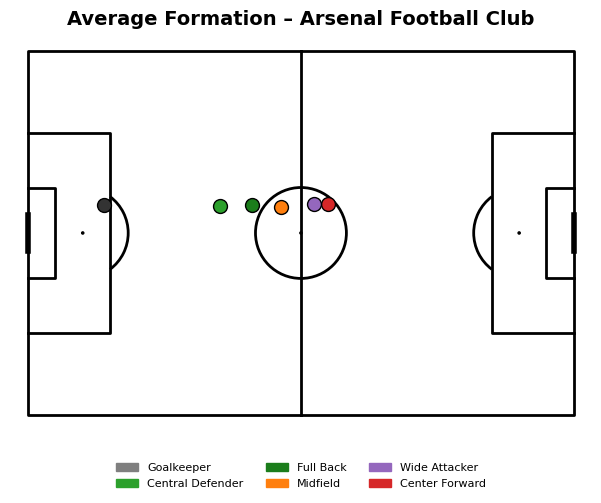

In [70]:
plot_team_formation(role_avg_league, "Arsenal Football Club")


## 2) Side-by-Side Comparison of Two Teams

In [71]:
def plot_team_vs_team(role_avg: pd.DataFrame, team1: str, team2: str, dot_size=300):
    """
    Compare average formations of two teams side by side.
    """
    def _aggregate(team_name):
        return (role_avg[role_avg["team_name"] == team_name]
                .groupby(["team_name","position_group"])
                [["x_norm","y_norm"]].mean().reset_index())

    t1, t2 = _aggregate(team1), _aggregate(team2)

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=6,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    def _plot(df, ax, title):
        for _, r in df.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c, edgecolors="black", ax=ax, zorder=3)
            ax.text(r["x_norm"], r["y_norm"]+1.5, r["position_group"], ha="center",
                    fontsize=8, weight="bold", color=c)
        ax.set_title(title, fontsize=12, weight="bold")

    _plot(t1, axs['pitch'][0], team1)
    _plot(t2, axs['pitch'][1], team2)

    fig.suptitle("Average Formations – Team Comparison", fontsize=16, weight="bold")
    plt.show()


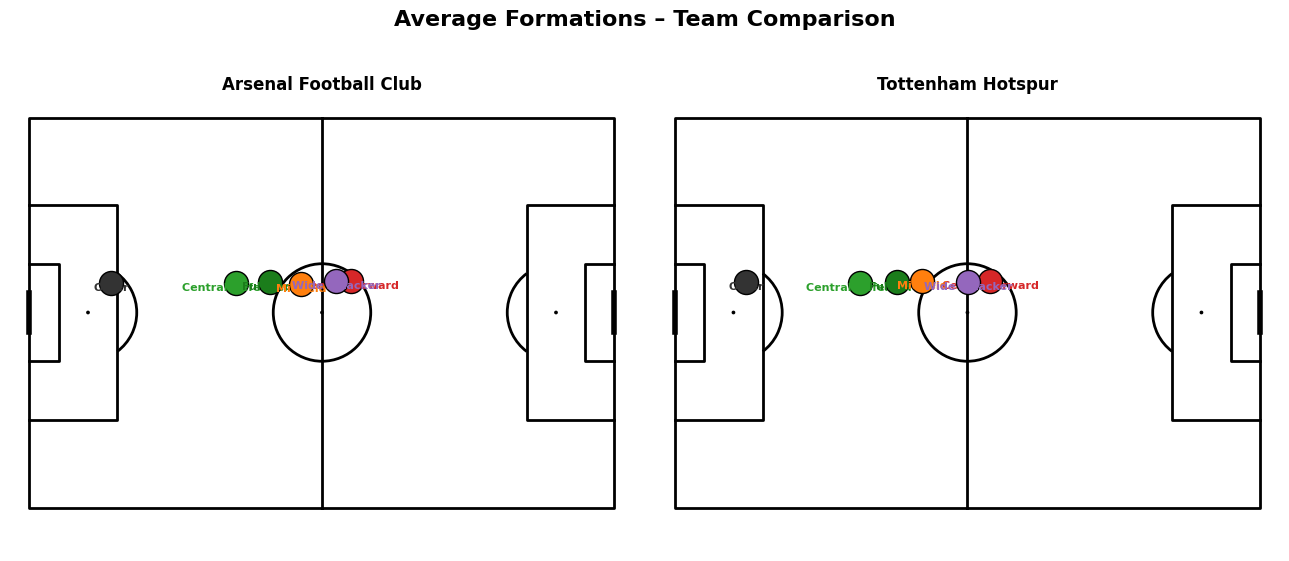

In [72]:
plot_team_vs_team(role_avg_league, "Arsenal Football Club", "Tottenham Hotspur")


### 3) Grid of All Teams in the League

In [75]:
def plot_league_formations(role_avg: pd.DataFrame, dot_size=200, ncols=4):
    """
    Grid visualization of all teams' average formations, with legend.
    """
    teams = sorted(role_avg["team_name"].unique())
    nrows = int(np.ceil(len(teams) / ncols))

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=nrows, ncols=ncols, figheight=3*nrows,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    # flatten axes (important!)
    axes = axs['pitch'].flatten()

    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    for idx, team in enumerate(teams):
        ax = axes[idx]
        agg = (role_avg[role_avg["team_name"] == team]
               .groupby(["team_name","position_group"])
               [["x_norm","y_norm"]].mean().reset_index())

        for _, r in agg.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c,
                          edgecolors="black", ax=ax, zorder=3)

        ax.set_title(team, fontsize=9, weight="bold")

    # legend (outside of subplots)
    import matplotlib.patches as mpatches
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               fontsize=8, frameon=False)

    fig.suptitle("Average Formations – League Overview", fontsize=16, weight="bold")
    plt.show()


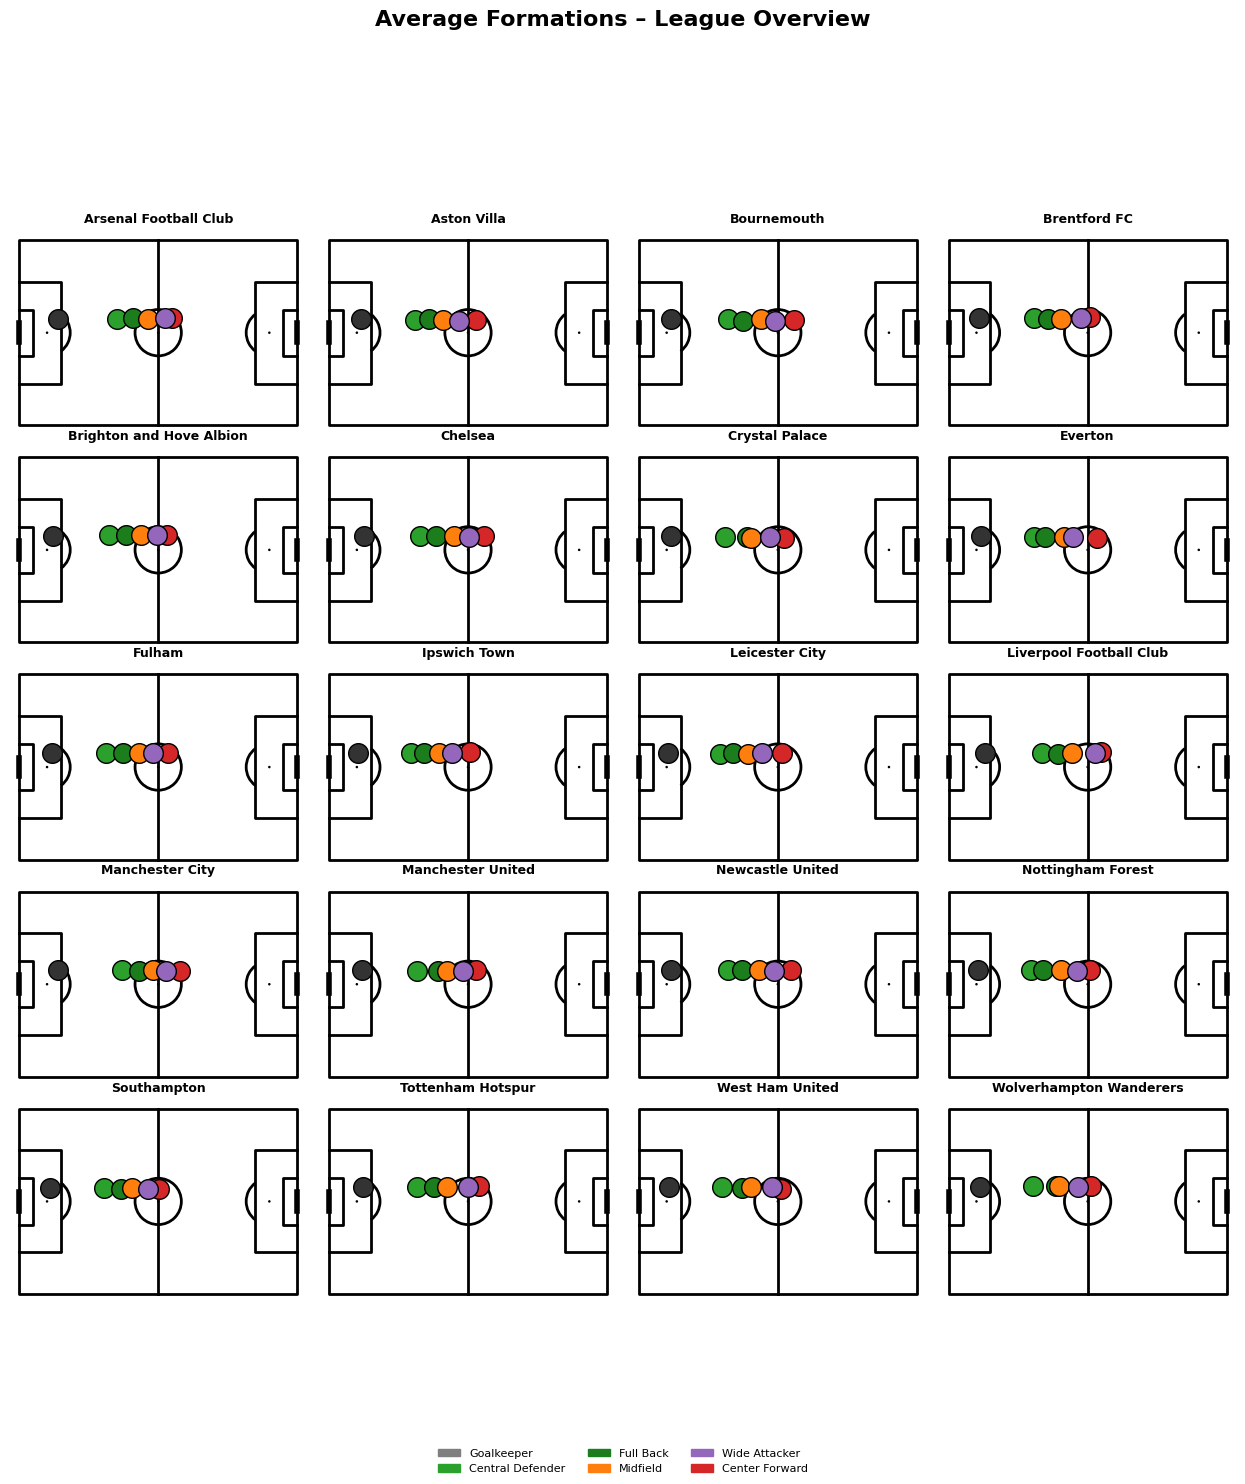

In [76]:
plot_league_formations(role_avg_league, ncols=4)


filter by phase (attack vs defense) before plotting, so you can present “league-wide attacking formations” vs “league-wide defensive formations”

Now we’ll switch from “single average point per role” to a distributional view per role and then do agglomerative clustering with an EMD-style distance between formations.

# Step 1 — Turn tracking points into role “heatmaps” (probability maps)

## What & why (in simple words)

For each team in a match, and for each role (e.g., Central Defender, Full Back, Midfield …), we collect all their (x_norm, y_norm) positions (already direction-normalized, ball-in-play).

We put these points into a 2D grid over the pitch (like pixels), count how many points fall into each cell, then normalize so that the whole grid sums to 1.
→ That gives a probability density of where this role tends to stand on the pitch for that match.

Later, we’ll compare two formations by comparing their role probability maps using Earth Mover’s Distance (EMD).

EMD idea (kid version): imagine the heatmap as little piles of sand. EMD asks: how much effort does it take to move the sand from one heatmap to reshape it into the other?

If two formations are similar, only a little sand needs to move → small EMD. If they’re very different, lots of sand must move → large EMD.

for now, we only build & save those per-role heatmaps (one file per team per match). this keeps memory usage tiny and speeds up later clustering.

### Code — build and save role heatmaps (per team–match)

📌 Assumptions: you already have per-match processed parquet in processed_tracking/ produced by your pipeline (so columns like x_norm, y_norm, ball_in_play, position_group, team_id, … exist).

In [92]:
# ==== CONFIG (adjust once) ==========================================
from pathlib import Path
import numpy as np
import pandas as pd

# Where your processed tracking parquet files live (one per match)
PROCESSED_DIR = Path("processed_tracking")

# Where we'll save role heatmaps (one .npz per match-team)
ROLEMAP_DIR = Path("role_heatmaps")
ROLEMAP_DIR.mkdir(parents=True, exist_ok=True)

# Grid resolution for heatmaps (coarser = faster, smoother)
NBINS_X, NBINS_Y = 24, 16  # works well; feel free to tweak

# Roles to include (match your position_group values)
ROLES = ["Central Defender", "Full Back", "Midfield", "Wide Attacker", "Center Forward"]
# You can add "Goalkeeper" / "Other" if you want them included.

# Minimum number of unique frames to accept a team sample (avoid tiny samples)
MIN_FRAMES_PER_TEAM = 300  # ~30 seconds at 10 fps
# ====================================================================

def _hist2d_prob(x, y, x_edges, y_edges):
    """
    2D histogram normalized to sum=1 (probability map). If no points, returns all zeros.
    """
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    s = H.sum()
    return H / s if s > 0 else H

def build_and_save_role_heatmaps_for_match(match_id: int,
                                           processed_dir: Path = PROCESSED_DIR,
                                           rolemaps_dir: Path = ROLEMAP_DIR,
                                           roles=ROLES,
                                           bins_x=NBINS_X, bins_y=NBINS_Y,
                                           min_frames_per_team=MIN_FRAMES_PER_TEAM):
    """
    For a given match:
      - loads processed tracking parquet
      - filters to ball-in-play, non-ball, valid coords
      - builds per-role probability maps for each team
      - saves one compressed .npz per (match_id, team_id)
    """
    f = processed_dir / f"{match_id}.parquet"
    if not f.exists():
        print(f"⚠️ No processed file for match {match_id}")
        return

    tr = pd.read_parquet(f)

    # basic safety checks
    needed_cols = {"x_norm","y_norm","is_ball","ball_in_play","position_group","team_id","team_name","team_short","frame"}
    missing = needed_cols - set(tr.columns)
    if missing:
        raise ValueError(f"Processed file {f} missing columns: {missing}")

    # keep valid player rows (not ball, ball-in-play, has coords)
    players = tr[(~tr["is_ball"]) & tr["ball_in_play"] & tr[["x_norm","y_norm"]].notna().all(axis=1)].copy()
    if players.empty:
        print(f"⚠️ No valid player rows after filtering for match {match_id}")
        return

    # ensure enough frames per team (avoid tiny/noisy samples)
    frames_per_team = (players.groupby(["match_id","team_id"])["frame"]
                       .nunique().rename("n_frames").reset_index())
    players = players.merge(frames_per_team, on=["match_id","team_id"], how="left")
    players = players[players["n_frames"] >= min_frames_per_team]
    if players.empty:
        print(f"⚠️ Match {match_id} — no team reached min_frames={min_frames_per_team}")
        return

    # define bin edges (StatsBomb/FIFA scale)
    x_edges = np.linspace(0, 105, bins_x+1)
    y_edges = np.linspace(0,  68, bins_y+1)

    # build per-team → per-role heatmaps
    for (team_id, team_name, team_short), gteam in players.groupby(["team_id","team_name","team_short"]):
        role_maps = {}
        for role in roles:
            grole = gteam[gteam["position_group"] == role]
            if grole.empty:
                role_maps[role] = np.zeros((bins_x, bins_y), dtype=float)
            else:
                H = _hist2d_prob(grole["x_norm"].values, grole["y_norm"].values, x_edges, y_edges)
                # histogram2d returns shape (bins_x, bins_y)
                role_maps[role] = H

        # save one file per team–match
        out = rolemaps_dir / f"{match_id}_{int(team_id)}.npz"
        np.savez_compressed(
            out,
            match_id=int(match_id),
            team_id=int(team_id),
            team_name=str(team_name),
            team_short=str(team_short),
            x_edges=x_edges,
            y_edges=y_edges,
            **{f"role__{r}": role_maps[r] for r in roles}
        )
        print(f"💾 saved {out.name} ({team_short}) with {len(roles)} roles @ {bins_x}x{bins_y} bins")


In [93]:
# pick one processed match to test
# (or set match_id = 1715920 or any known id you processed)
any_file = next(PROCESSED_DIR.glob("*.parquet"))
match_id = int(any_file.stem)
match_id


1986708

In [94]:
# build + save role heatmaps for that match
build_and_save_role_heatmaps_for_match(match_id)


💾 saved 1986708_60.npz (Crystal Palace) with 5 roles @ 24x16 bins
💾 saved 1986708_754.npz (Brentford FC) with 5 roles @ 24x16 bins


In [95]:
# load the saved npz to inspect its contents
test_npz = ROLEMAP_DIR / f"{match_id}_"  # we don't know team_id yet; list them
list(ROLEMAP_DIR.glob(f"{match_id}_*.npz"))


[PosixPath('role_heatmaps/1986708_60.npz'),
 PosixPath('role_heatmaps/1986708_754.npz')]

In [96]:
# pick one team file and inspect shapes and sums
sample_file = list(ROLEMAP_DIR.glob(f"{match_id}_*.npz"))[0]
data = np.load(sample_file, allow_pickle=True)
print("keys:", list(data.keys()))
print("team:", data["team_short"])
print("x_edges shape:", data["x_edges"].shape, "y_edges shape:", data["y_edges"].shape)

# each role map should sum to ~1 (probability map)
for role in ROLES:
    H = data[f"role__{role}"]
    print(role, H.shape, "sum=", float(H.sum()))


keys: ['match_id', 'team_id', 'team_name', 'team_short', 'x_edges', 'y_edges', 'role__Central Defender', 'role__Full Back', 'role__Midfield', 'role__Wide Attacker', 'role__Center Forward']
team: Crystal Palace
x_edges shape: (25,) y_edges shape: (17,)
Central Defender (24, 16) sum= 1.0
Full Back (24, 16) sum= 1.0
Midfield (24, 16) sum= 1.0
Wide Attacker (24, 16) sum= 1.0
Center Forward (24, 16) sum= 1.0


You should see:

- Each role__… array has shape (NBINS_X, NBINS_Y) and sum ~ 1.0 (within floating-point error).

- If a role didn’t appear, its map is all zeros (sum = 0.0). That’s fine; the clustering code will handle it.

(Optional) Quick visual check for one role heatmap

This helps you “see” the probability map for one role.

In [101]:
data

NpzFile 'role_heatmaps/1986708_60.npz' with keys: match_id, team_id, team_name, team_short, x_edges...

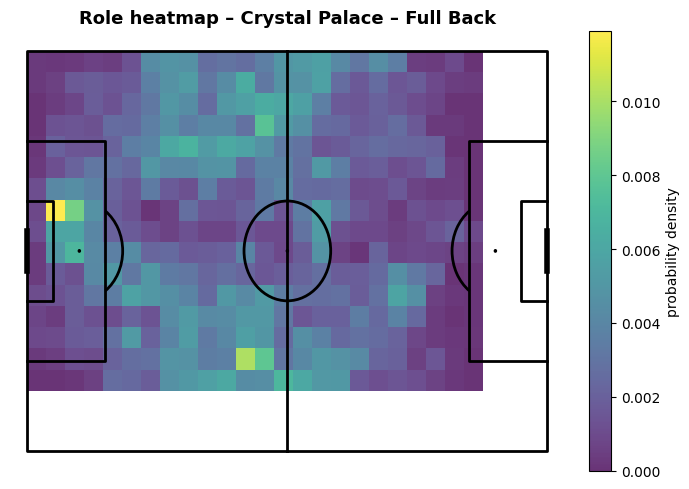

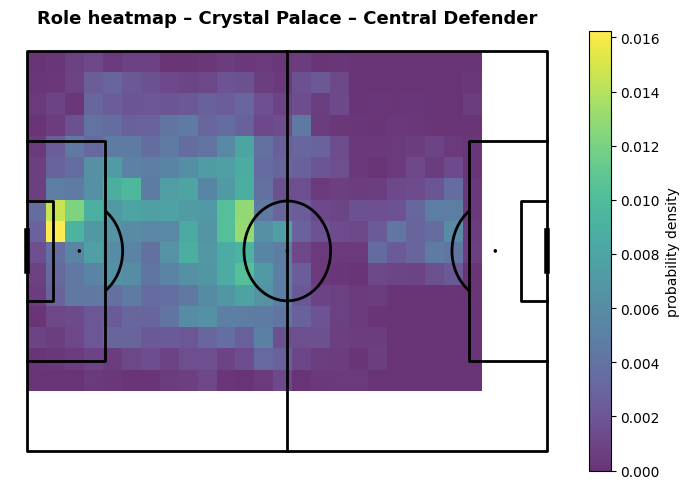

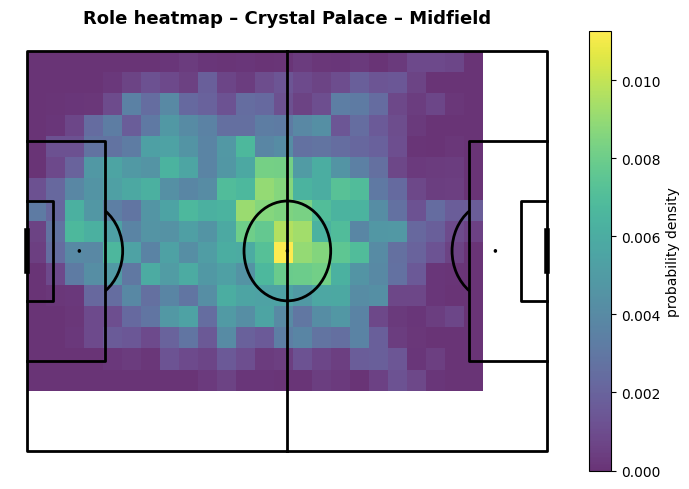

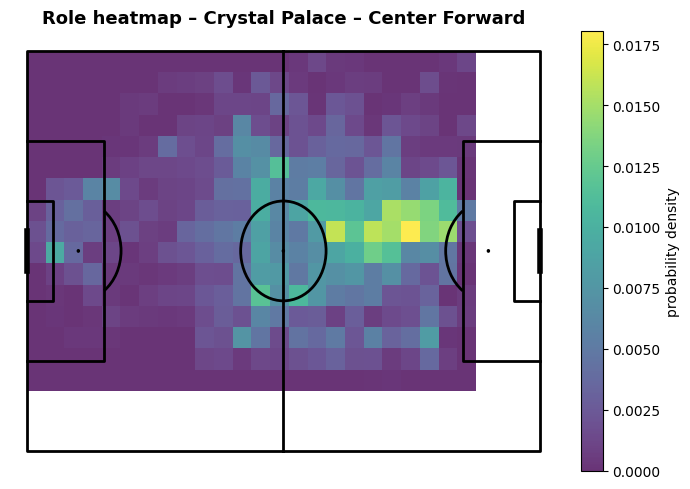

In [103]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

for role_to_plot in ["Full Back", "Central Defender", "Midfield", "Center Forward"]:

    H = data[f"role__{role_to_plot}"]
    x_edges = data["x_edges"]; y_edges = data["y_edges"]

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7,5))

    # use bin edges (not centers) as extent
    im = ax.imshow(H.T, origin="lower",
                extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                aspect="auto", alpha=0.8)

    ax.set_title(f"Role heatmap – {str(data['team_short'])} – {role_to_plot}", fontsize=13, weight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="probability density")
    plt.show()


# Step 2 — Distance between two formations (EMD on role heatmaps)

## What are we measuring?

We want a number that says how different two team formations are.
Each formation (for one team in one match) is represented by role heatmaps—probability maps over the pitch for:

Central Defender, Full Back, Midfield, Wide Attacker, Center Forward (your ROLES)

## Earth Mover’s Distance (EMD), in plain words

Imagine each heatmap as piles of sand spread across the pitch.

EMD asks: how much work is needed to move the sand from heatmap A to reshape it into heatmap B?

If two formations are similar (players stand in similar areas), only small moves are needed → small EMD.

If they’re very different (e.g., back 3 vs back 4, 1 striker vs 2), lots of sand must move → large EMD.

## 2D vs 1D EMD (and why we use 1D marginals)

True 2D EMD requires optimal transport on a 2D grid (heavier, extra deps).

A fast, effective approximation is to compare x- and y- marginals separately:

Collapse the 2D heatmap along y to get a distribution over x (left–right shape).

Collapse along x to get a distribution over y (depth/front–back shape).

Compute 1D EMD (a.k.a. Wasserstein distance) on each marginal, then sum them.

This captures the key formation differences (back line height, width, 1 vs 2 strikers, etc.) with simple code.

## What exactly we’ll compute

For two formations A and B:

1. For each role:

Take A’s role heatmap H_A and B’s role heatmap H_B.

Compute x-marginals (H.sum(axis=1)) and y-marginals (H.sum(axis=0)).

Normalize each marginal so it sums to 1 (probability).

Compute 1D EMD between A and B marginals using the bin centers as coordinates.

Add the two numbers: emd_x + emd_y.

2. Sum over all roles to get the final formation distance.

Notes:

If a role map is empty in both formations (no data), it contributes 0.

Heatmaps must use the same bin edges across matches (we made that true when saving the .npz files).

In [120]:
import numpy as np
from scipy.stats import wasserstein_distance

# Make sure this matches what you used when saving
ROLES = ["Central Defender", "Full Back", "Midfield", "Wide Attacker", "Center Forward"]

def _marginals_xy(H: np.ndarray):
    """
    From a 2D heatmap H (bins_x, bins_y), return:
      - mx: distribution over x bins (sum along y)
      - my: distribution over y bins (sum along x)
    """
    mx = H.sum(axis=1)  # shape (bins_x,)
    my = H.sum(axis=0)  # shape (bins_y,)
    return mx, my

def _bin_centers(edges: np.ndarray):
    """Centers from bin edges."""
    return 0.5 * (edges[:-1] + edges[1:])

def load_sample_npz(npz_path: str) -> dict:
    """
    Load one team–match formation sample saved by Step 1 and return a dict:
      {
        'match_id', 'team_id', 'team_short',
        'x_edges', 'y_edges',
        'roles': { role_name: 2D array (bins_x, bins_y) }
      }
    """
    d = np.load(npz_path, allow_pickle=True)
    sample = {
        "match_id": int(d["match_id"]),
        "team_id": int(d["team_id"]),
        "team_short": str(d["team_short"]),
        "x_edges": d["x_edges"],
        "y_edges": d["y_edges"],
        "roles": {}
    }
    for r in ROLES:
        sample["roles"][r] = d[f"role__{r}"]
    return sample

from scipy.stats import wasserstein_distance

def formation_distance(sampleA: dict, sampleB: dict) -> float:
    """
    Sum over roles of [ EMD_x + EMD_y ] on the role histograms' marginals.
    Handles empty role maps safely.
    """
    if not (np.allclose(sampleA["x_edges"], sampleB["x_edges"]) and
            np.allclose(sampleA["y_edges"], sampleB["y_edges"])):
        raise ValueError("Bin edges differ between samples – ensure consistent binning when saving.")

    x_centers = _bin_centers(sampleA["x_edges"])
    y_centers = _bin_centers(sampleA["y_edges"])

    total = 0.0
    for role in ROLES:
        HA = sampleA["roles"][role]
        HB = sampleB["roles"][role]

        # both empty → no contribution
        if HA.sum() == 0 and HB.sum() == 0:
            continue

        Ax, Ay = _marginals_xy(HA)
        Bx, By = _marginals_xy(HB)

        # normalize safely
        def safe_norm(v):
            if v.sum() > 0 and np.isfinite(v.sum()):
                return v / v.sum()
            else:
                # fallback: uniform distribution
                return np.ones_like(v) / len(v)

        Ax, Ay = safe_norm(Ax), safe_norm(Ay)
        Bx, By = safe_norm(Bx), safe_norm(By)

        emd_x = wasserstein_distance(x_centers, x_centers, Ax, Bx)
        emd_y = wasserstein_distance(y_centers, y_centers, Ay, By)

        total += (emd_x + emd_y)

    return float(total)



In [121]:
from pathlib import Path

ROLEMAP_DIR = Path("role_heatmaps")

# pick two saved formation files (two teams or two matches)
files = sorted(ROLEMAP_DIR.glob("*.npz"))
print(f"Found {len(files)} samples")
assert len(files) >= 2, "You need at least two saved samples to test distance."

sA = load_sample_npz(str(files[0]))
sB = load_sample_npz(str(files[1]))

d = formation_distance(sA, sB)
print(f"Distance between {sA['team_short']} (match {sA['match_id']}) and {sB['team_short']} (match {sB['match_id']}): {d:.3f}")


Found 756 samples
Distance between Manchester U (match 1650385) and Fulham (match 1650385): 36.477


If two samples are the same team in similar matches, you should see a smaller number.

If they’re very different (e.g., back-3 vs back-4), you should see a larger number.

✅ What you’ll have after Step 2

A function that compares any two formations (team–match samples) as a single distance number.

This is the building block for:

making a distance matrix across all samples, and

running agglomerative clustering (Step 3), where we’ll pick e.g. 6 clusters and then visualize the clusters (Step 4).

# Step 3 — Build a Distance Matrix and Run Agglomerative Clustering

## 🔎 Why do we need a distance matrix?
- We now have a way to compute a **distance between two formations** (from Step 2).  
- To cluster multiple formations, we need to compute the **distance for every pair** of samples.  
- This gives us a **distance matrix** `D` of shape `(n_samples, n_samples)`.  
  - `D[i, j]` = distance between formation `i` and formation `j`.  
  - `D[i, i] = 0` (a formation is identical to itself).  

## 🧩 What is agglomerative clustering?
- **Agglomerative clustering** starts with each sample in its own cluster.  
- Then, step by step, it merges the two closest clusters (based on the distance matrix).  
- This forms a **hierarchy** (a dendrogram).  
- You can “cut” the tree at a chosen height to get a certain number of clusters (e.g., 6).  

## 📏 What is a “high” vs “low” distance?
- A **low distance** means the formations are very similar (little sand needs to move).  
- A **high distance** means the formations are very different.  
- The *absolute values* depend on your binning and scale.  
  - Example: in our test, distance ≈ **27** between Crystal Palace and Brentford is somewhere in the middle.  
  - Once you compute all pairwise distances, you’ll see the full range (e.g., 5 → 60). Then you can tell which are relatively low or high.  

---



In [113]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def build_distance_matrix(samples):
    """
    Build a full pairwise distance matrix between formation samples.
    samples: list of dicts (from load_sample_npz)
    Returns:
        D (n x n numpy array), order of samples
    """
    n = len(samples)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            d = formation_distance(samples[i], samples[j])
            D[i, j] = D[j, i] = d
    return D

# === Example usage on your current samples (one match only) ===

# Collect all samples for the match
files = sorted(ROLEMAP_DIR.glob("*.npz"))
samples = [load_sample_npz(str(f)) for f in files]

# Build distance matrix
D = build_distance_matrix(samples)
print("Distance matrix:\n", D)

# Run agglomerative clustering
# ✅ In scikit-learn >= 1.2, use `metric` instead of `affinity`
agg = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='average')
labels = agg.fit_predict(D)

for s, lab in zip(samples, labels):
    print(f"Team {s['team_short']} → Cluster {lab}")

Distance matrix:
 [[ 0.         36.47662077 25.08844619 ... 78.755171   37.67817011
  41.51317137]
 [36.47662077  0.         43.45552716 ... 53.54746656 49.55697753
  34.63398176]
 [25.08844619 43.45552716  0.         ... 81.38374436 26.62794385
  31.249368  ]
 ...
 [78.755171   53.54746656 81.38374436 ...  0.         81.7281885
  59.86200361]
 [37.67817011 49.55697753 26.62794385 ... 81.7281885   0.
  29.62222142]
 [41.51317137 34.63398176 31.249368   ... 59.86200361 29.62222142
   0.        ]]
Team Manchester U → Cluster 0
Team Fulham → Cluster 0
Team Liverpool → Cluster 0
Team Ipswich Town → Cluster 0
Team West Ham → Cluster 0
Team Aston Villa → Cluster 0
Team Arsenal → Cluster 0
Team Wolverhampton → Cluster 0
Team Brighton → Cluster 0
Team Everton → Cluster 0
Team Newcastle → Cluster 0
Team Southampton → Cluster 0
Team Crystal Palace → Cluster 0
Team Brentford FC → Cluster 0
Team Manchester City → Cluster 0
Team Chelsea → Cluster 0
Team Tottenham → Cluster 0
Team Leicester → Cluste

# Step 4 — Visualize the Dendrogram and Cluster Prototypes

## 🌳 Why a dendrogram?
- Agglomerative clustering produces a **hierarchy** of clusters.  
- A **dendrogram** is a tree diagram that shows at which distance different formations (samples) were merged.  
- By looking at the dendrogram, you can decide where to “cut” the tree (e.g., 6 clusters).  

## 👥 What are cluster prototypes?
- Once we cut the hierarchy into clusters, we can summarize each cluster by a **prototype formation**.  
- The prototype is created by:
  1. Averaging the **role heatmaps** across all samples in the cluster.  
  2. Computing the **expected x,y location** of each role (the centroid of its heatmap).  
  3. Plotting these average role points on the pitch.  

## 📊 Why do this?
- The dendrogram helps you decide the number of clusters.  
- The prototypes let you see the **typical formation shapes** in each cluster (e.g., 4-4-2 vs 4-2-3-1).  

---


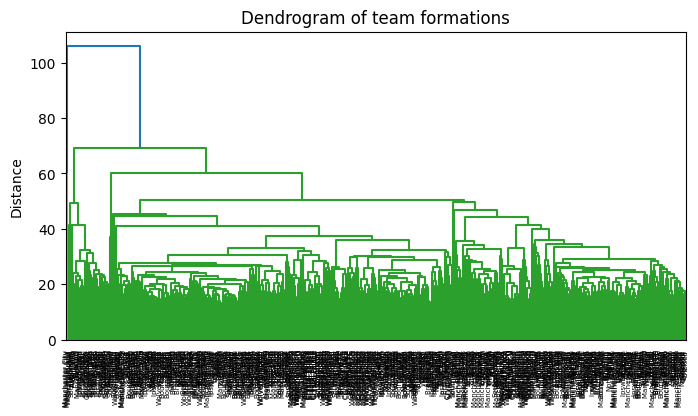

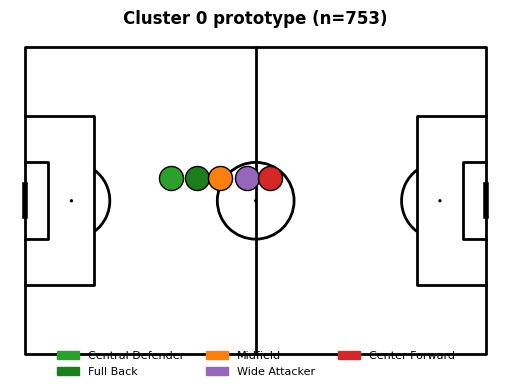

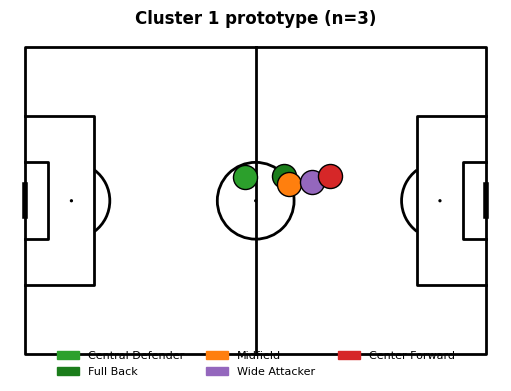

In [114]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from mplsoccer import Pitch
import matplotlib.patches as mpatches

# --- Dendrogram helper ---
def plot_dendrogram(D, samples, method="average"):
    """
    Plot dendrogram from precomputed distance matrix D.
    """
    # linkage needs condensed distance matrix
    from scipy.spatial.distance import squareform
    Z = linkage(squareform(D), method=method)
    plt.figure(figsize=(8, 4))
    dendrogram(Z, labels=[s["team_short"] for s in samples], leaf_rotation=90)
    plt.title("Dendrogram of team formations")
    plt.ylabel("Distance")
    plt.show()

# --- Cluster prototype helper ---
def _marginals_xy(H: np.ndarray):
    mx = H.sum(axis=1)
    my = H.sum(axis=0)
    return mx, my

def _bin_centers(edges: np.ndarray):
    return 0.5 * (edges[:-1] + edges[1:])

def _expected_xy(H, x_centers, y_centers):
    if H.sum() <= 0:
        return np.nan, np.nan
    mx, my = _marginals_xy(H)
    if mx.sum() > 0: mx = mx / mx.sum()
    if my.sum() > 0: my = my / my.sum()
    ex = float((mx * x_centers).sum())
    ey = float((my * y_centers).sum())
    return ex, ey

ROLE_COLORS = {
    "Central Defender": "#2ca02c",
    "Full Back":        "#1b7d1b",
    "Midfield":         "#ff7f0e",
    "Wide Attacker":    "#9467bd",
    "Center Forward":   "#d62728",
}

def plot_cluster_prototypes(samples, labels, n_clusters):
    """
    For each cluster, compute average role heatmaps → expected positions,
    and plot as prototype formation.
    """
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    for cid in range(n_clusters):
        subset = [s for s in samples if labels[samples.index(s)] == cid]
        if not subset:
            continue

        # average role heatmaps
        mean_maps = {r: np.zeros((len(x_centers), len(y_centers)), dtype=float) for r in ROLES}
        for s in subset:
            for r in ROLES:
                mean_maps[r] += s["roles"][r]
        for r in ROLES:
            total = mean_maps[r].sum()
            if total > 0:
                mean_maps[r] /= total

        # expected positions
        role_points = []
        for r in ROLES:
            ex, ey = _expected_xy(mean_maps[r], x_centers, y_centers)
            role_points.append((r, ex, ey))

        # plot
        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        fig, ax = pitch.draw(figsize=(6, 4))

        for r, ex, ey in role_points:
            if np.isfinite(ex) and np.isfinite(ey):
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=300, c=c, edgecolors="black", ax=ax, zorder=3)

        handles = [mpatches.Patch(color=ROLE_COLORS.get(r, "#333333"), label=r) for r in ROLES]
        ax.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.5, -0.05))

        ax.set_title(f"Cluster {cid} prototype (n={len(subset)})", fontsize=12, weight="bold")
        plt.show()

# === Example usage (with your 2 samples only) ===
# Dendrogram
plot_dendrogram(D, samples)

# Cluster prototypes (2 clusters here, since only 2 teams in the match)
plot_cluster_prototypes(samples, labels, n_clusters=2)


# 📌 Reminder — Preparing the Input for Step 4

Currently:
- `ROLEMAP_DIR` only contains `.npz` files for **1 match** → 2 team samples.
- Dendrogram looks trivial because there are only 2 points.

To get a useful dendrogram + cluster prototypes:
1. Loop over **all processed matches** in your league.  
2. For each match, run `build_and_save_role_heatmaps_for_match(match_id)`.  
3. This will fill `ROLEMAP_DIR` with one `.npz` file **per team per match**.  
   - Example: `1715920_12345.npz` (match id + team id).  

Once `ROLEMAP_DIR` has, say, 380 matches × 2 teams = 760 samples,  
the dendrogram will show rich branching, and cluster prototypes will reveal **formation archetypes**.


In [ ]:
# === Build role heatmaps for the whole league ===

# load all processed parquet files
processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))

#for f in processed_files:
    #match_id = int(f.stem)
    #build_and_save_role_heatmaps_for_match(match_id)


💾 saved 1650385_31.npz (Manchester U) with 5 roles @ 24x16 bins
💾 saved 1650385_48.npz (Fulham) with 5 roles @ 24x16 bins
💾 saved 1650961_2.npz (Liverpool) with 5 roles @ 24x16 bins
💾 saved 1650961_752.npz (Ipswich Town) with 5 roles @ 24x16 bins
💾 saved 1651700_37.npz (West Ham) with 5 roles @ 24x16 bins
💾 saved 1651700_39.npz (Aston Villa) with 5 roles @ 24x16 bins
💾 saved 1651701_3.npz (Arsenal) with 5 roles @ 24x16 bins
💾 saved 1651701_52.npz (Wolverhampton) with 5 roles @ 24x16 bins
💾 saved 1651702_41.npz (Everton) with 5 roles @ 24x16 bins
💾 saved 1651702_308.npz (Brighton) with 5 roles @ 24x16 bins
💾 saved 1651703_32.npz (Newcastle) with 5 roles @ 24x16 bins
💾 saved 1651703_58.npz (Southampton) with 5 roles @ 24x16 bins
💾 saved 1653146_60.npz (Crystal Palace) with 5 roles @ 24x16 bins
💾 saved 1653146_754.npz (Brentford FC) with 5 roles @ 24x16 bins
💾 saved 1654741_40.npz (Manchester City) with 5 roles @ 24x16 bins
💾 saved 1654741_49.npz (Chelsea) with 5 roles @ 24x16 bins
💾 save

# ✅ Next
- After this loop, `ROLEMAP_DIR` will contain **all team–match samples**.  
- Then you can rerun **Step 4 (dendrogram + prototypes)** and it will finally show:
  - Many branches in the dendrogram.  
  - Cluster prototypes that look like **4-4-2, 4-2-3-1, 3-5-2, etc.**.  


# Step 4 — Visualize the Dendrogram and Cluster Prototypes (All Matches)

## 🌳 Dendrogram
- Shows how all team–match formations are related.  
- Each leaf = one team’s formation in one match.  
- Branch height = how different the formations are.  
- Cutting at a certain height (e.g. 6) gives formation clusters.

## 👥 Cluster Prototypes
- After clustering, we average role heatmaps across all samples in a cluster.  
- Then we plot the **expected x,y positions** of each role on the pitch.  
- This shows the typical “shape” of that cluster (e.g. 4-4-2, 4-2-3-1, etc.).  

## 📊 Workflow
1. Load all team–match `.npz` files from `ROLEMAP_DIR`.  
2. Build the **distance matrix** between all samples.  
3. Run **AgglomerativeClustering** with `metric="precomputed"`.  
4. Plot:
   - **Dendrogram** (can hide labels if too many).  
   - **Cluster prototypes** (league-level formation archetypes).  


📂 Loaded 756 samples (team–match formations)


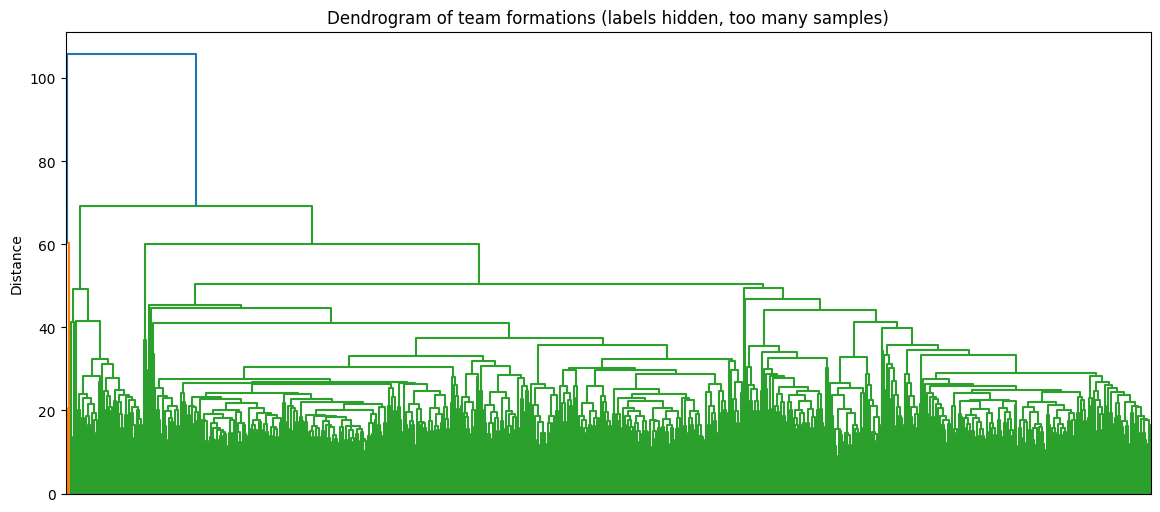

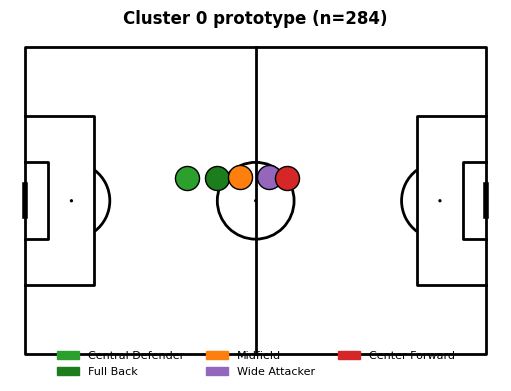

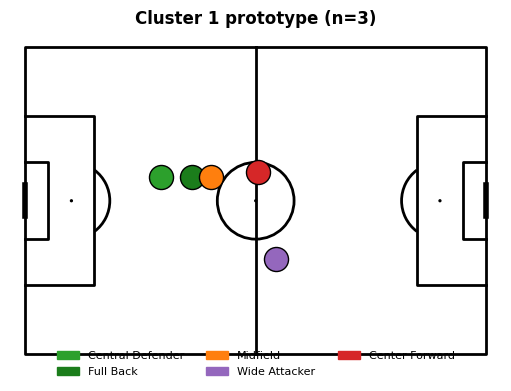

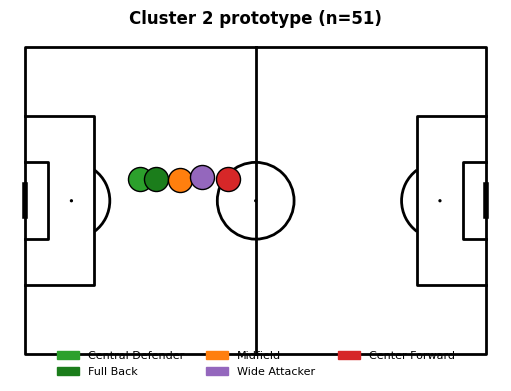

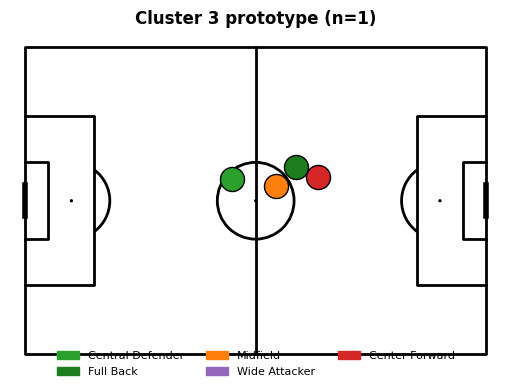

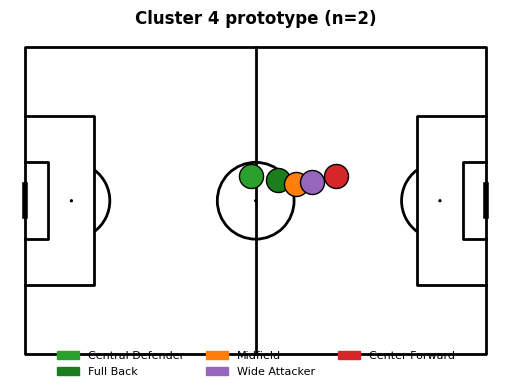

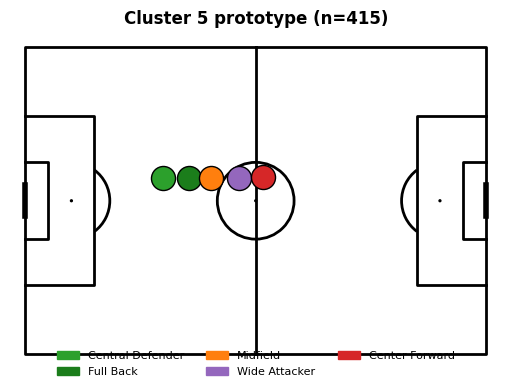

In [115]:
# === Step 4: Dendrogram and Cluster Prototypes ===

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
import numpy as np

# 1) Load all samples (one per team per match)
files = sorted(ROLEMAP_DIR.glob("*.npz"))
samples = [load_sample_npz(str(f)) for f in files]
print(f"📂 Loaded {len(samples)} samples (team–match formations)")

# 2) Build distance matrix
D = build_distance_matrix(samples)

# 3) Run clustering (choose how many clusters you want)
n_clusters = 6
agg = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
labels = agg.fit_predict(D)

# Attach cluster labels to samples
for s, lab in zip(samples, labels):
    s["cluster"] = int(lab)

# --- Dendrogram ---
def plot_dendrogram(D, samples, method="average", max_labels=50):
    Z = linkage(squareform(D), method=method)
    plt.figure(figsize=(14, 6))
    if len(samples) > max_labels:
        dendrogram(Z, no_labels=True, leaf_rotation=90, leaf_font_size=8)
        plt.title("Dendrogram of team formations (labels hidden, too many samples)")
    else:
        dendrogram(Z, labels=[f"{s['team_short']}-{s['match_id']}" for s in samples],
                   leaf_rotation=90, leaf_font_size=8)
        plt.title("Dendrogram of team formations")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(D, samples)

# --- Cluster Prototypes ---
def _marginals_xy(H: np.ndarray):
    mx = H.sum(axis=1); my = H.sum(axis=0)
    return mx, my

def _bin_centers(edges: np.ndarray):
    return 0.5 * (edges[:-1] + edges[1:])

def _expected_xy(H, x_centers, y_centers):
    if H.sum() <= 0: return np.nan, np.nan
    mx, my = _marginals_xy(H)
    if mx.sum() > 0: mx = mx / mx.sum()
    if my.sum() > 0: my = my / my.sum()
    ex = float((mx * x_centers).sum())
    ey = float((my * y_centers).sum())
    return ex, ey

ROLE_COLORS = {
    "Central Defender": "#2ca02c",
    "Full Back":        "#1b7d1b",
    "Midfield":         "#ff7f0e",
    "Wide Attacker":    "#9467bd",
    "Center Forward":   "#d62728",
}

def plot_cluster_prototypes(samples, n_clusters):
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    for cid in range(n_clusters):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            continue

        # Average role heatmaps in this cluster
        mean_maps = {r: np.zeros((len(x_centers), len(y_centers)), dtype=float) for r in ROLES}
        for s in subset:
            for r in ROLES:
                mean_maps[r] += s["roles"][r]
        for r in ROLES:
            total = mean_maps[r].sum()
            if total > 0:
                mean_maps[r] /= total

        # Expected positions
        role_points = []
        for r in ROLES:
            ex, ey = _expected_xy(mean_maps[r], x_centers, y_centers)
            role_points.append((r, ex, ey))

        # Plot prototype
        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        fig, ax = pitch.draw(figsize=(6, 4))

        for r, ex, ey in role_points:
            if np.isfinite(ex) and np.isfinite(ey):
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=300, c=c, edgecolors="black", ax=ax, zorder=3)

        # Legend
        handles = [mpatches.Patch(color=ROLE_COLORS.get(r, "#333333"), label=r) for r in ROLES]
        ax.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.5, -0.05))

        ax.set_title(f"Cluster {cid} prototype (n={len(subset)})", fontsize=12, weight="bold")
        plt.show()

plot_cluster_prototypes(samples, n_clusters=n_clusters)


# Step 5 — Per-Team Cluster Distribution

## 🎯 Goal
- After clustering, each sample (team–match formation) has a **cluster label**.  
- By grouping these labels per team, we can see:
  - Which formations (clusters) a team uses most often.  
  - How much they vary (stable vs flexible teams).  

## 📊 Method
1. Collect cluster assignments per `team_name`.  
2. Count how many times each cluster appears.  
3. Normalize to percentages → shows distribution across clusters.  
4. Visualize as a **stacked bar chart** (teams × cluster proportions).  

This tells us, for example:  
- Arsenal: 70% cluster 2 (4-2-3-1), 20% cluster 5 (3-4-3), 10% cluster 1.  
- Brentford: 60% cluster 1 (4-4-2), 40% cluster 3 (5-3-2).  


In [117]:
sample = samples[0]
print(sample.keys())


dict_keys(['match_id', 'team_id', 'team_short', 'x_edges', 'y_edges', 'roles', 'cluster'])


<Figure size 1000x600 with 0 Axes>

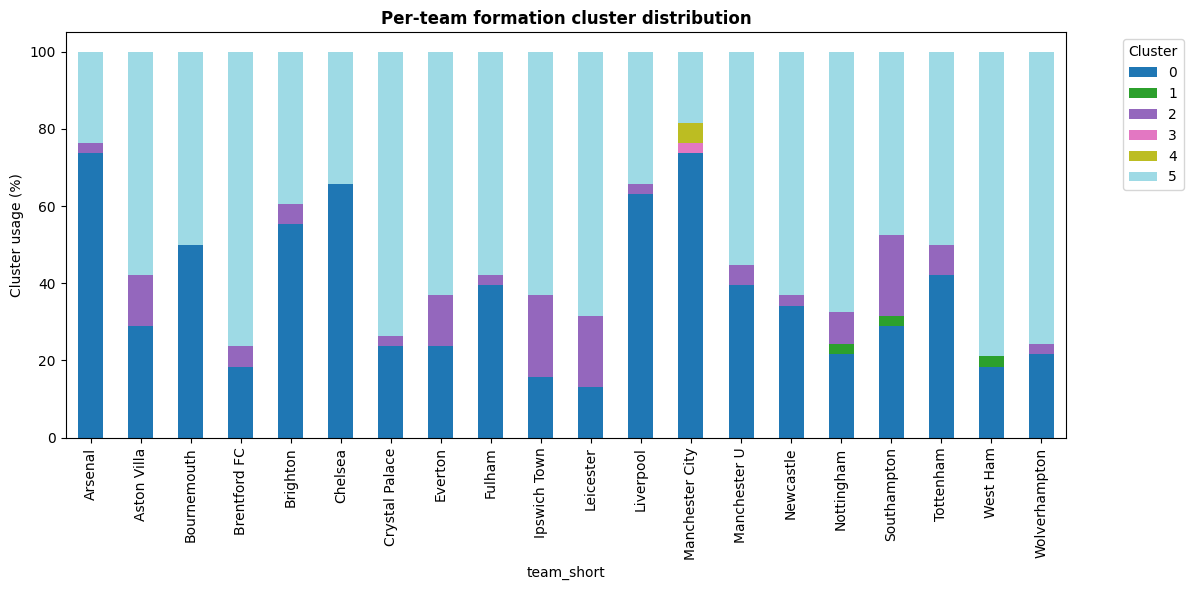

Arsenal formation distribution:
   team_short  cluster  count    percent
0    Arsenal        0     28  73.684211
1    Arsenal        2      1   2.631579
2    Arsenal        5      9  23.684211


In [125]:
import pandas as pd
import seaborn as sns

# 1) Build DataFrame of assignments
rows = []
for s in samples:
    rows.append({
        "match_id": s["match_id"],
        "team_id": s["team_id"],
        "team_short": s["team_short"],
        "team_short": s["team_short"],
        "cluster": s["cluster"],
    })
assign_df = pd.DataFrame(rows)

# 2) Count cluster usage per team
cluster_dist = (
    assign_df.groupby(["team_short", "cluster"])
             .size()
             .reset_index(name="count")
)

# 3) Normalize to percentages
cluster_dist["percent"] = cluster_dist.groupby("team_short")["count"].transform(
    lambda x: 100 * x / x.sum()
)

# 4) Pivot for visualization
pivot_df = cluster_dist.pivot(index="team_short", columns="cluster", values="percent").fillna(0)

# 5) Plot stacked bar chart
plt.figure(figsize=(10, 6))
pivot_df.plot(kind="bar", stacked=True, colormap="tab20", figsize=(12, 6))
plt.ylabel("Cluster usage (%)")
plt.title("Per-team formation cluster distribution", weight="bold")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Example: look at Arsenal specifically
arsenal_dist = cluster_dist[cluster_dist["team_short"] == "Arsenal"]
print("Arsenal formation distribution:\n", arsenal_dist)


# Step 6 — Interpreting Clusters as Tactical Formations

## 🧩 The problem
- Current prototypes use **role groups** (Central Defender, Midfield, etc.).
- That compresses several players into one dot (e.g. 4 defenders → 1 circle).
- You can’t distinguish between **4-4-2** vs **3-5-2**.

## 🎯 The solution
- Instead of plotting only role centroids, compute **player-level averages** inside each cluster.
- Approach:
  1. For each cluster, gather all frames from all samples assigned to that cluster.
  2. For each `player_id` (or consistent jersey/role index), compute their **average normalized x,y**.
  3. Plot those average positions → you’ll see 10 outfielders + 1 goalkeeper in shape.
- This way, clusters look like **actual team formations**: four in defense, four in midfield, two up top, etc.


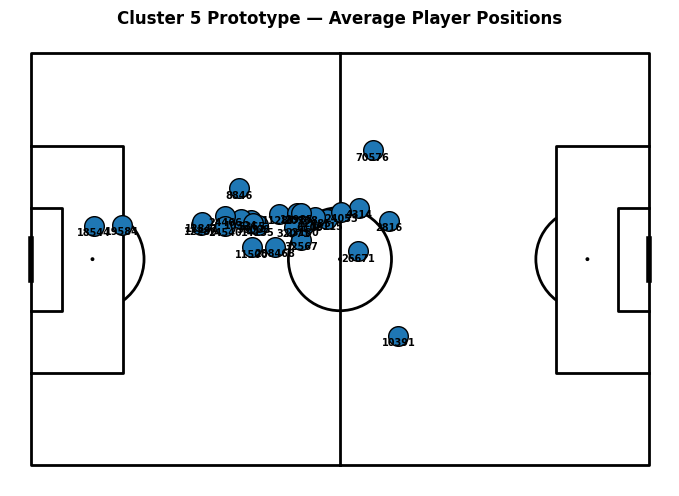

In [128]:
def plot_cluster_player_prototype(samples, cluster_id, tr_league, dot_size=200):
    """
    Plot the average 11-player formation for a given cluster.
    - samples: list of formation samples with cluster assignments
    - cluster_id: which cluster to visualize
    - tr_league: processed tracking dataframe for the league (with x_norm, y_norm, team_id, cluster)
    """

    subset = [s for s in samples if s["cluster"] == cluster_id]
    team_ids = [s["team_id"] for s in subset]
    match_ids = [s["match_id"] for s in subset]

    # filter tracking data belonging to those matches/teams
    sub_tr = tr_league[
        tr_league["match_id"].isin(match_ids) &
        tr_league["team_id"].isin(team_ids) &
        (~tr_league["is_ball"])
    ].copy()

    # average position per player_id
    avg_positions = (sub_tr.groupby("player_id")[["x_norm", "y_norm"]]
                              .mean()
                              .reset_index())

    # keep only players with enough detections
    avg_positions = avg_positions.dropna()

    # --- plot ---
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7, 5))

    pitch.scatter(avg_positions["x_norm"], avg_positions["y_norm"],
                  s=dot_size, c="#1f77b4", edgecolors="black", ax=ax, zorder=3)

    # label players
    for _, row in avg_positions.iterrows():
        ax.text(row["x_norm"], row["y_norm"]+2, str(int(row["player_id"])),
                ha="center", fontsize=7, weight="bold")

    ax.set_title(f"Cluster {cluster_id} Prototype — Average Player Positions", fontsize=12, weight="bold")
    plt.show()

# Example usage (after clustering done and samples assigned)
plot_cluster_player_prototype(samples, cluster_id=5, tr_league=tr_with_pos)


# Step 7 — Professional Visualization of Clustered Formations

## 🎯 Goal
- Show each cluster’s **formation archetype**.
- Background: all team–match mean role positions in that cluster (faded).
- Foreground: cluster’s **median/central formation** (bold, black).
- Title: cluster id + percentage of all samples → popularity indicator.

## 📊 Interpretation
- You’ll see clear tactical patterns:
  - 4 defenders in a line (4-4-2, 4-2-3-1).
  - 3 at the back (3-5-2, 3-4-3).
  - Striker count (1 vs 2 vs 3).  
- The % label tells you how common each formation type is across the league.


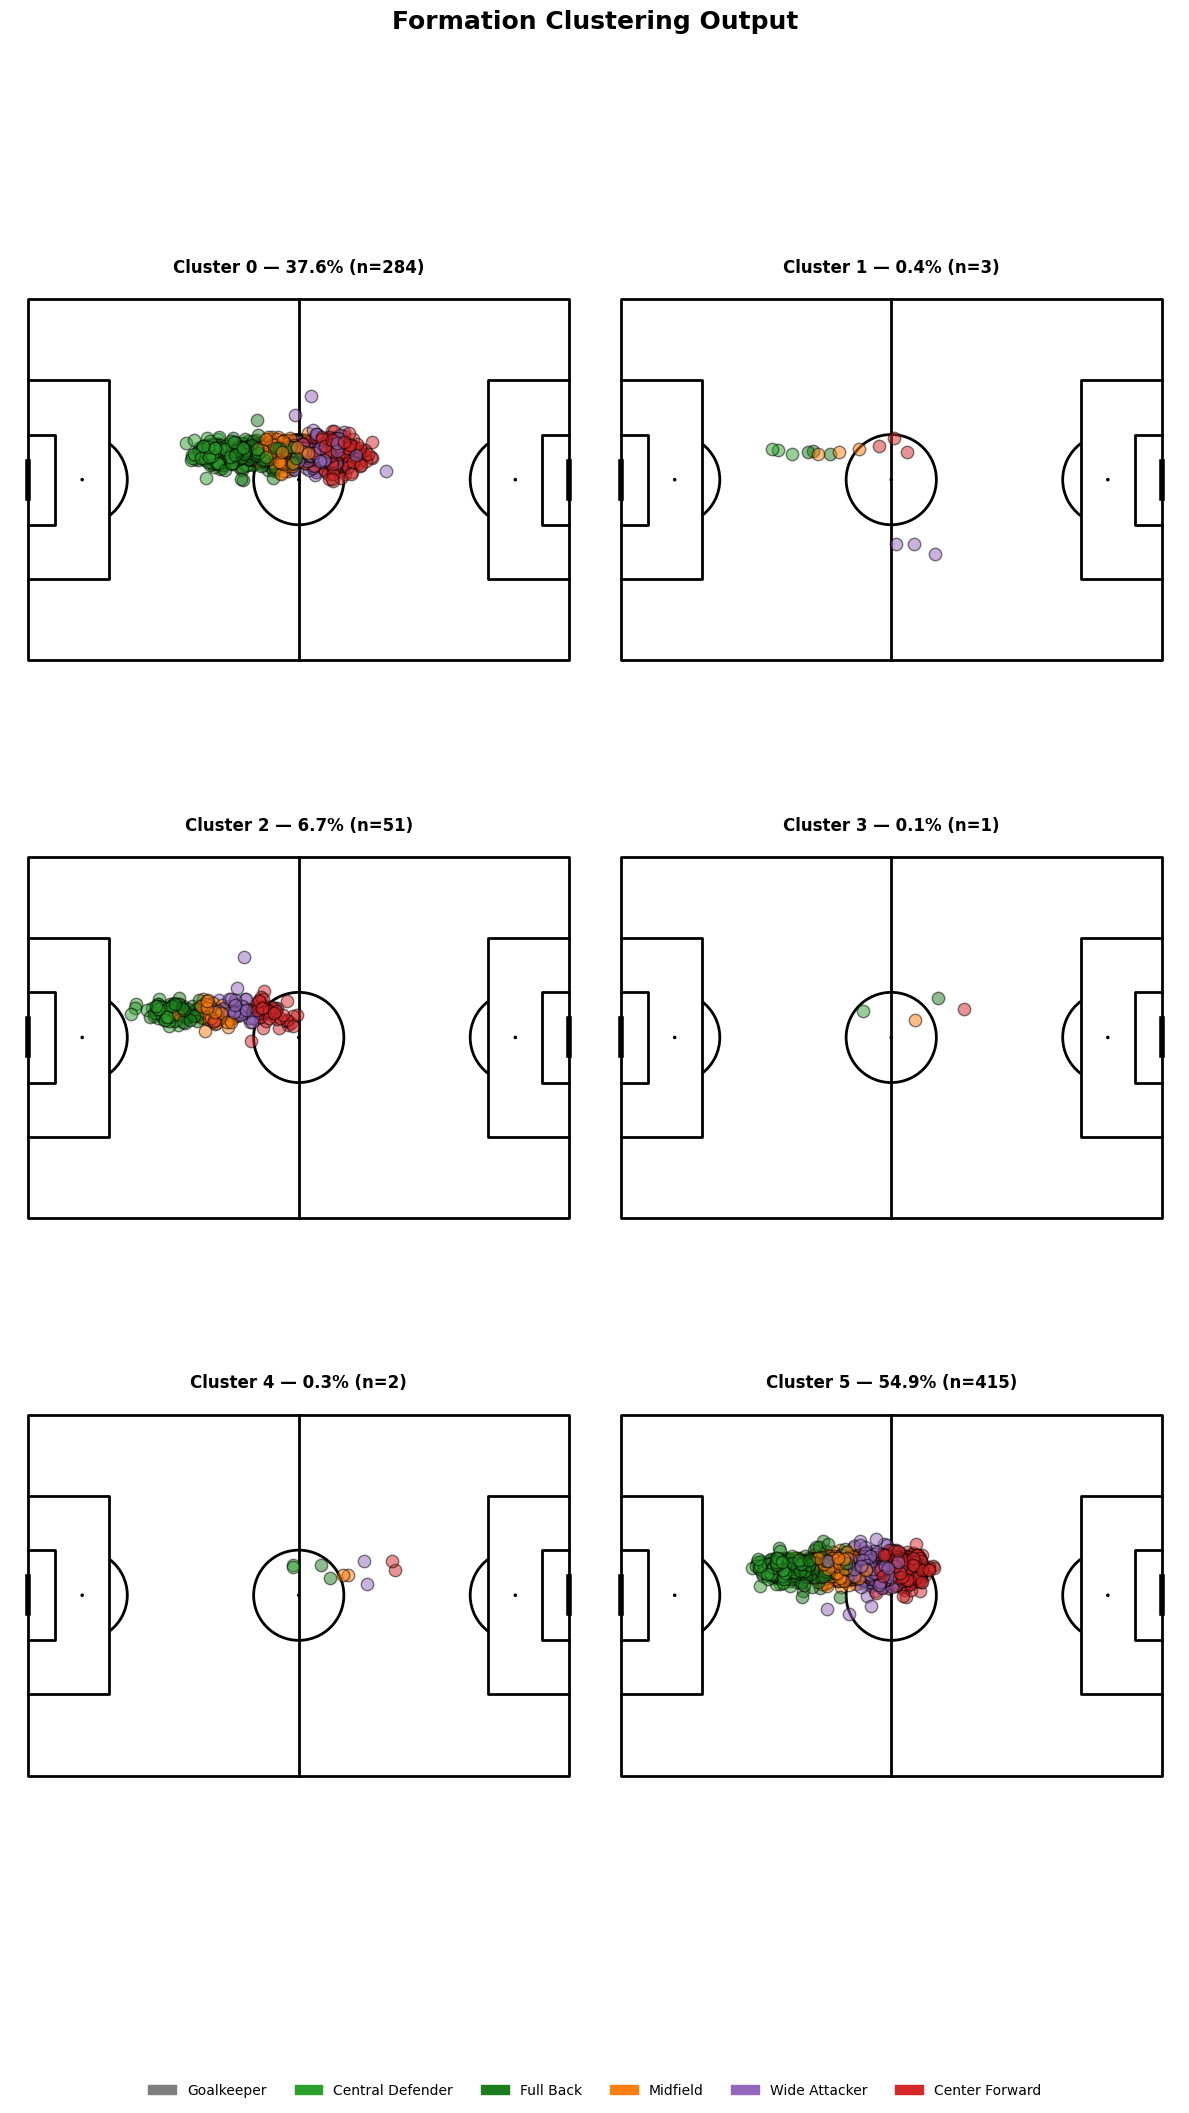

In [136]:
def plot_cluster_formations(samples, n_clusters, dot_size=80, alpha=0.5,
                            cols=3, figheight=6):
    """
    Plot all samples' role positions for each cluster.
    - Larger subplot pitches (controlled by cols & figheight)
    - One shared legend at bottom for role colors
    """
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    # Arrange clusters into grid
    rows = int(np.ceil(n_clusters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*figheight))
    axes = axes.flatten()

    for cid, ax in enumerate(axes):
        if cid >= n_clusters:
            ax.axis("off")
            continue

        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Scatter all role points from all samples in this cluster
        for s in subset:
            role_points = compute_expected_positions(s, x_centers, y_centers)
            for r, ex, ey in role_points:
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=dot_size, c=c, alpha=alpha,
                              edgecolors="black", ax=ax, zorder=3)

        # Title with popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}% (n={len(subset)})",
                     fontsize=12, weight="bold")

    # Create one shared legend (roles → colors)
    handles = [mpatches.Patch(color=ROLE_COLORS[r], label=r) for r in ROLE_COLORS]
    fig.legend(handles=handles, loc="lower center", ncol=len(ROLE_COLORS),
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle("Formation Clustering Output", fontsize=18, weight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # leave space for legend + title
    plt.show()

# Example: larger plots with shared legend
plot_cluster_formations(samples, n_clusters=n_clusters, cols=2, figheight=7)




# Step 9 — Clustering Formations with KMeans / GMM

## 🎯 Goal
- Represent each team–match (or team–half) by **11 player average positions** (x,y).
- Cluster these 22-dimensional vectors (11 players × 2 coordinates).
- Use KMeans or GMM to discover typical formations:
  - **KMeans** → simpler, balanced partitions, good for coarse 4–6 clusters.
  - **GMM** → allows soft assignments (a team may mix between formations).

## 📊 Workflow
1. **Extract samples**
   - For each team in each match, compute average `x_norm, y_norm` for 11 players (exclude ball).
   - Flatten into one vector `[x1,y1,x2,y2,...,x11,y11]`.

2. **Cluster**
   - Apply KMeans or GMM with `n_clusters ~ 6–8`.
   - Each cluster = one typical formation.

3. **Visualize**
   - For each cluster, plot **all samples** (faded) + **cluster centroid** (bold).
   - Overlay role-colored dots.
   - Title = cluster id + inferred formation (e.g., 4-4-2) + frequency.

4. **Interpret**
   - Count players in defensive/middle/attacking thirds → auto-label as “4-4-2”, etc.
   - Report % usage league-wide.


In [140]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

def build_player_samples(tr_with_pos):
    """
    Create one sample per team–match: 11 average player positions.
    """
    samples = []
    grouped = tr_with_pos[~tr_with_pos["is_ball"]].groupby(["match_id","team_id"])
    for (match_id, team_id), df in grouped:
        avg = df.groupby("player_id")[["x_norm","y_norm"]].mean().dropna()
        if len(avg) < 10:  # filter out incomplete lineups
            continue
        vec = avg.values.flatten()[:22]  # 11 players × 2 coords
        if len(vec) == 22:
            samples.append({"match_id":match_id,"team_id":team_id,"vec":vec,"positions":avg})
    return samples

# Build samples
samples = build_player_samples(tr_with_pos)

# Prepare matrix
X = np.vstack([s["vec"] for s in samples])


n_clusters = min(6, len(samples))  # can’t exceed number of samples

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

for s, lab in zip(samples, labels):
    s["cluster"] = lab




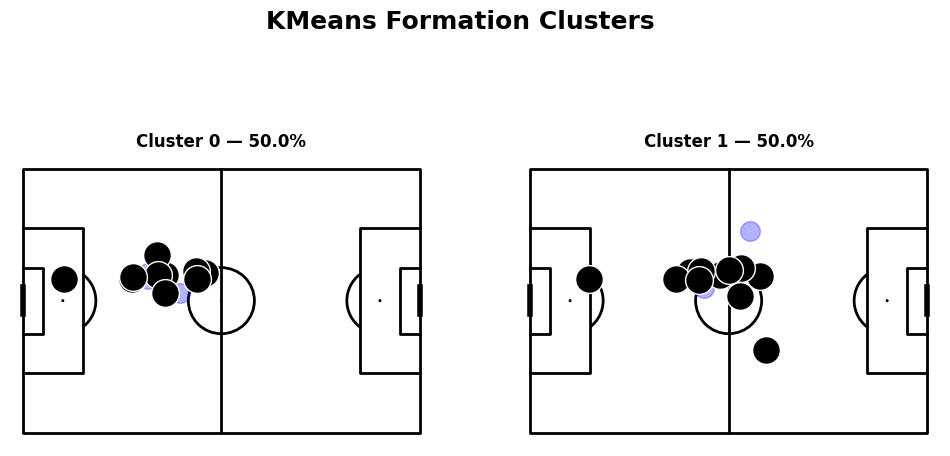

In [141]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=200, alpha=0.3):
    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 6))
    if n_clusters == 1:
        axes = [axes]

    for cid, ax in enumerate(axes):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Plot centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black", edgecolors="white", ax=ax, zorder=3)

        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}%", fontsize=12, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=18, weight="bold")
    plt.show()

# Example
plot_kmeans_formations(samples, kmeans, n_clusters)


# Step 10 — Run KMeans on All Matches

## 🎯 Goal
- Loop through all processed match files in `PROCESSED_DIR`.
- Extract **one sample per team–match** (average positions of 11 players).
- Build a dataset of hundreds of samples across the season.
- Cluster using **KMeans (n_clusters=6–8)**.
- Visualize clusters → each subplot = one typical formation (4-4-2, 4-2-3-1, etc.).


In [142]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def build_league_samples(processed_dir):
    """
    Loop over all processed tracking files and extract one sample per team–match.
    Each sample = average x,y positions of 11 players (ball excluded).
    """
    samples = []
    files = list(Path(processed_dir).glob("*.parquet"))

    for f in files:
        df = pd.read_parquet(f)
        grouped = df[~df["is_ball"]].groupby(["match_id", "team_id"])
        for (match_id, team_id), g in grouped:
            avg = g.groupby("player_id")[["x_norm","y_norm"]].mean().dropna()
            if len(avg) < 10:  # skip incomplete teams
                continue
            vec = avg.values.flatten()[:22]  # 11 players × 2 coords
            if len(vec) == 22:
                samples.append({
                    "match_id": match_id,
                    "team_id": team_id,
                    "team_name": g["team_name"].iloc[0],
                    "vec": vec,
                    "positions": avg
                })
    print(f"✅ Built {len(samples)} samples from {len(files)} matches")
    return samples

# Example usage
samples = build_league_samples(PROCESSED_DIR)


✅ Built 756 samples from 378 matches


In [145]:
# Stack feature vectors
X = np.vstack([s["vec"] for s in samples])

# Choose number of clusters
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Attach cluster labels back
for s, lab in zip(samples, labels):
    s["cluster"] = lab


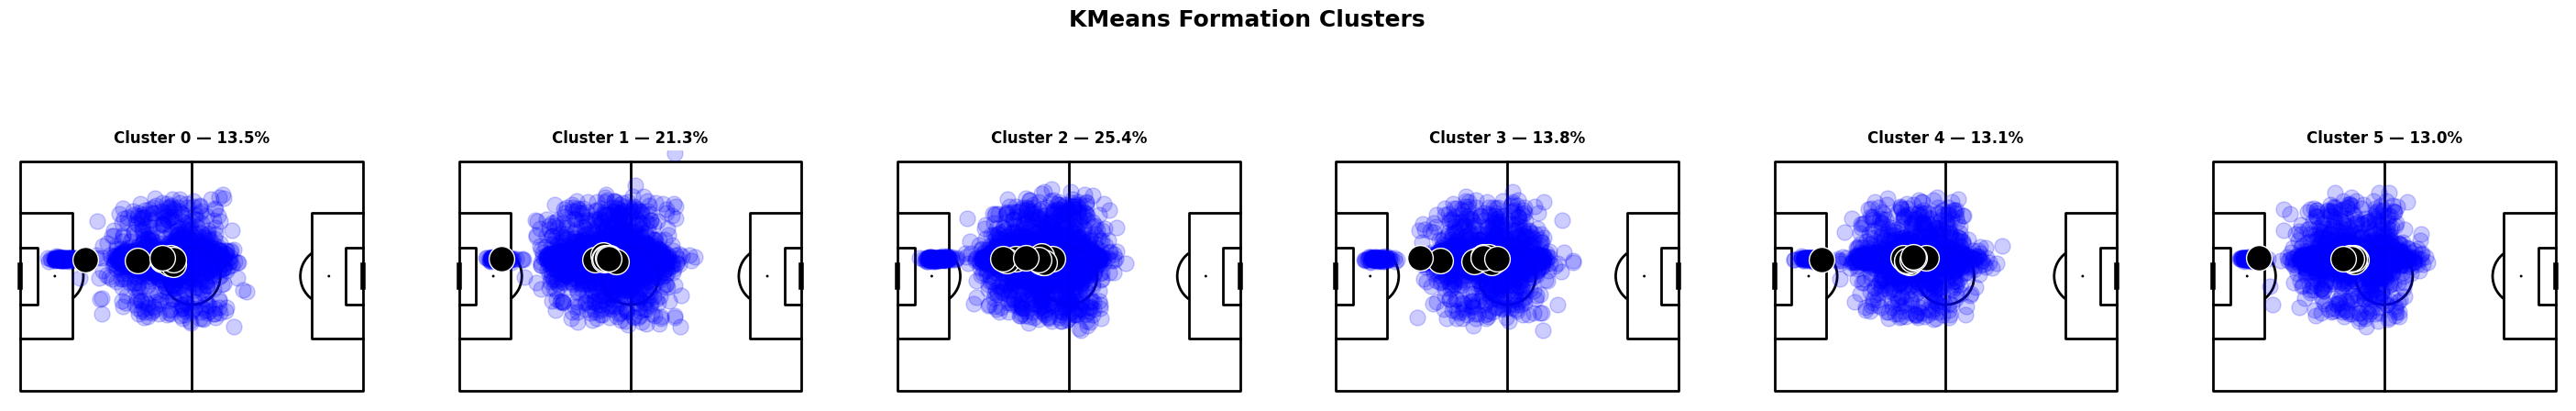

In [146]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=150, alpha=0.2):
    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 6))
    if n_clusters == 1:
        axes = [axes]

    for cid, ax in enumerate(axes):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded blue)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Plot cluster centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black",
                      edgecolors="white", ax=ax, zorder=3)

        # Popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}%", fontsize=12, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=18, weight="bold")
    plt.show()

# Example usage
plot_kmeans_formations(samples, kmeans, n_clusters)


In [152]:
from sklearn.cluster import KMeans

def infer_formation_label(centroid, n_lines=3):
    """
    Infer a formation label (e.g., 4-4-2) by clustering players along x-axis.
    centroid: (11,2) array with [x,y].
    n_lines: expected number of tactical lines (def/mid/att).
    """
    X = centroid[:, 0].reshape(-1,1)  # only x-axis
    km = KMeans(n_clusters=n_lines, random_state=0, n_init=10).fit(X)
    labels = km.labels_

    # Count players in each line (sorted from defense → attack)
    counts = []
    for line in np.argsort(km.cluster_centers_.ravel()):
        counts.append((labels == line).sum())

    return "-".join(map(str, counts))


In [153]:
centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
formation_label = infer_formation_label(centroid)

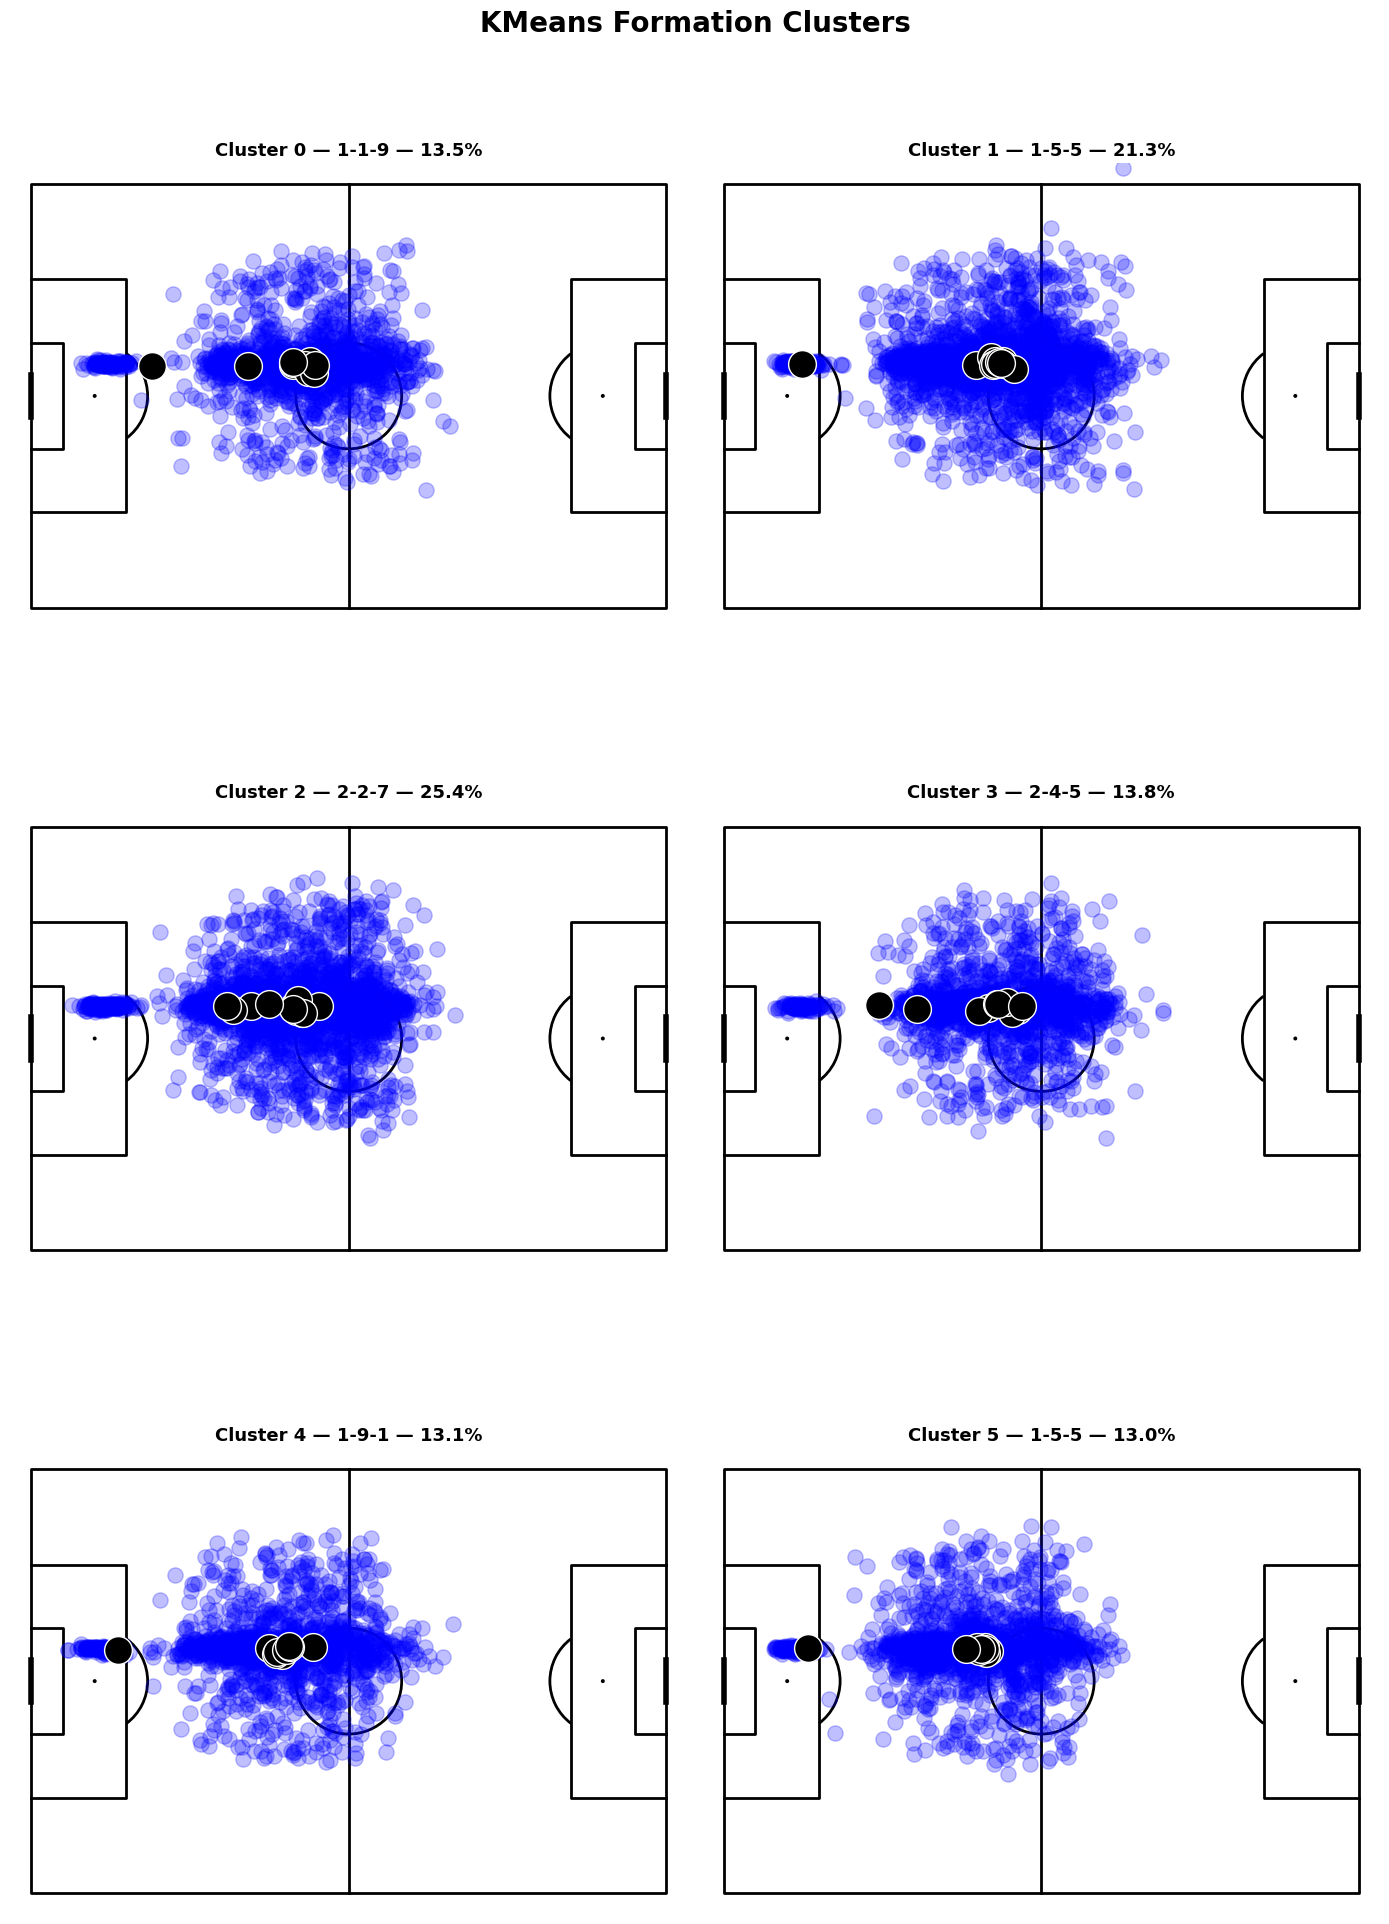

In [154]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=120, alpha=0.25, cols=3):
    rows = int(np.ceil(n_clusters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*7))
    axes = axes.flatten()

    for cid, ax in enumerate(axes):
        if cid >= n_clusters:
            ax.axis("off")
            continue

        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded blue)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Cluster centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black",
                      edgecolors="white", ax=ax, zorder=3)

        # Auto formation label
        formation_label = infer_formation_label(centroid)

        # Popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {formation_label} — {pct:.1f}%", fontsize=13, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=20, weight="bold")
    plt.tight_layout()
    plt.show()

# Example usage
plot_kmeans_formations(samples, kmeans, n_clusters, cols=2)
